## Imports iniciais

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st 
import math as mt

## Abro o arquivo e vejos suas informações

In [2]:
df_games = pd.read_csv('games.csv')
print(df_games.head()) # Exibindo as primeiras 5 linhas do DataFrame
print()
print(df_games.info()) # Exibindo informações sobre o DataFrame, como o número de linhas, colunas e tipos de dados
print()
print(df_games.sample(15)) # Exibindo uma amostra aleatória de 5 linhas do DataFrame

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):


## Limpeza dos dados
- Primeiro coloco todas as colunas em minusculas
- Depois converto os dados para os tipos necessários
- Averiguo os ausentes e tomo decisões de como lidar com eles

In [3]:
df_games.columns = [col.lower() for col in df_games.columns]
print(df_games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')


In [4]:
df_games['year_of_release'] = df_games['year_of_release'].astype('Int64') # Convertendo a coluna year_of_release para o tipo inteiro
# Isso foi feito para que possamos realizar operações numéricas de forma mais eficiente.


### Verificando dados ausentes

In [5]:
print(df_games.isna().sum()) # Verificando a quantidade de valores nulos em cada coluna do DataFrame

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64


In [6]:
#print(df_games[df_games['name'].isna()]) # Verificando as linhas com valores nulos na coluna 'name'
df_games = df_games.dropna(subset=['name', 'genre']) # Removendo as linhas com valores nulos na coluna 'name' e 'genre'

Os 2 unicos ausentes de 'name' e 'genre' são valores com poucas informações e a exclusão deles não trará diferenças significativas para a análise.
Ambos estão ausentes na mesma linha

In [7]:
df_games['rating'] = df_games['rating'].fillna('Unknown') # Preenchendo os valores nulos na coluna 'rating' com a string 'Unknown'
df_games['user_score'] = pd.to_numeric(df_games['user_score'], errors='coerce') # Convertendo a coluna 'user_score' para o tipo numérico, substituindo valores não numéricos por NaN

### Motivo dos ausentes
Os ausentes de 'name' e 'genre' não possuem demais informações, supõe-se que não foram preenchidos corretamente
OS ausentes de 'year_of_release'...
já os ausentes referentes a avaliação ('critic_score', 'user_score' e 'rating')

### Decisão com os ausentes

- Os 269 ausentes de 'year_of_release' ainda possuem informações de vendas, foi optado por deixa-los para que agregem em calculos futuros.\
- Em relação a coluna 'rating', apenas foi substituido para o valor 'Unknown'.\
- A coluna 'user_score' possui valores como 'tbd', ou seja, ainda não foram definidos. A conversão para numérico transforma esses valores em nulos, o que pode ajudar em calculos futuros\
- Por fim a coluna 'critic_score' possui nulos, porém altera-los com a média ou a mediana, faz com que jogos ruins recebam notas maiores comparadas ao 'user_score' e a 'rating', por isso, foi optado em não fazer nada com esses valores

### Soma de todas as vendas

In [8]:
df_games['total_sales'] = df_games[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1) # Somando as vendas de todas as regiões para cada jogo
df_games = df_games[['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales', 'rating', 'user_score']] # Reorganizando as colunas do DataFrame

## Analisando os dados

In [9]:
count_games_by_year = df_games.groupby('year_of_release').size().reset_index(name='count') # Contando a quantidade de jogos lançados por ano
print(count_games_by_year.sample(15, random_state=42).sort_index()) # Exibindo uma amostra aleatória de 15 linhas do DataFrame count_games_by_year, ordenadas pelo índice

    year_of_release  count
4              1984     14
6              1986     21
8              1988     15
9              1989     17
12             1992     43
13             1993     60
15             1995    219
16             1996    263
17             1997    289
24             2004    762
25             2005    939
26             2006   1006
29             2009   1426
32             2012    653
35             2015    606


Com uma amostra da quantidade de jogos lançados por ano, pode-se confirmar que há uma diferença consideravelmente grande na quantidade lançada do século XX para o XXI

In [10]:
sales_by_platform = df_games.groupby(['platform',])['total_sales'].sum().reset_index(name='total_sales') # Agrupando as vendas totais por plataforma e ano de lançamento
print(sales_by_platform.sort_values('total_sales', ascending=False).head(5)) # Exibindo as 5 plataformas com maior quantidade de vendas totais

   platform  total_sales
16      PS2      1255.77
28     X360       971.42
17      PS3       939.65
26      Wii       907.51
4        DS       806.12


As 5 plataformas com mais vendas são PS2, X360, PS3, Wii e DS

In [11]:
top_5_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS'] # Selecionando as 5 plataformas com maior quantidade de vendas totais
top5_sales_platform = (df_games[df_games['platform'].isin(top_5_platforms)].groupby(['platform', 'year_of_release'], dropna=False)['total_sales'].sum().reset_index())
# Agrupando as vendas totais por plataforma e ano de lançamento, considerando apenas as 5 plataformas selecionadas

## Criando um grafico de distribuição

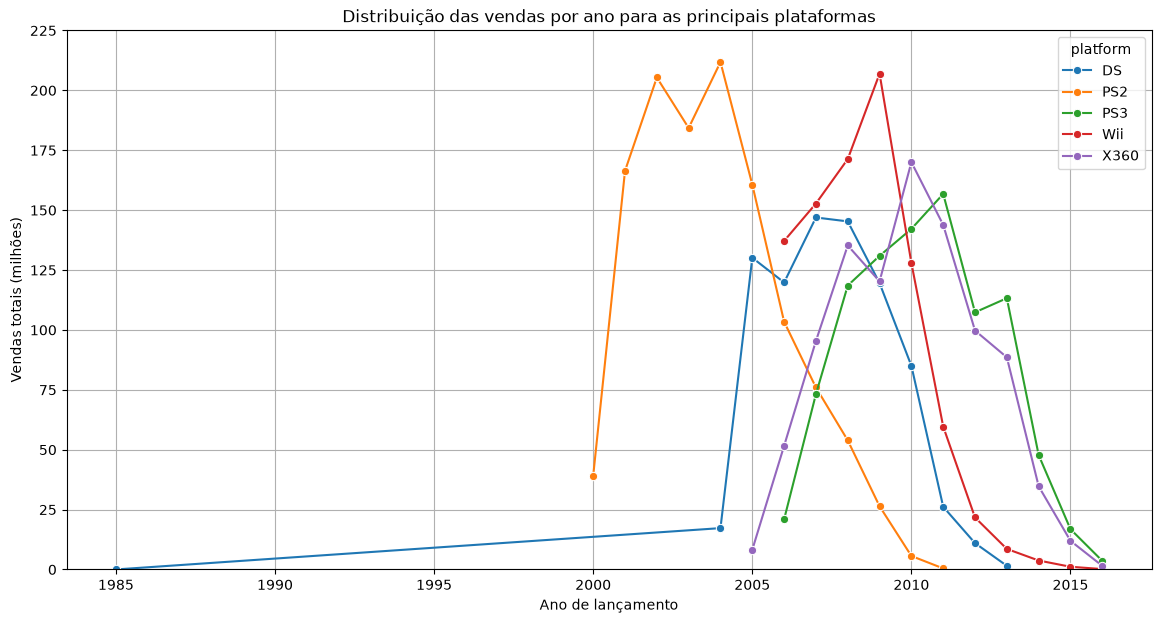

In [12]:
sales_by_platform_year = df_games[df_games['platform'].isin(top_5_platforms)].groupby(['platform', 'year_of_release'], dropna=False)['total_sales'].sum().reset_index()
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=sales_by_platform_year,
    x='year_of_release',
    y='total_sales',
    hue='platform',
    marker='o'
) # Criando um gráfico de linha para visualizar a distribuição das vendas por ano para as principais plataformas
plt.title('Distribuição das vendas por ano para as principais plataformas') # Adicionando um título ao gráfico
plt.xlabel('Ano de lançamento') # Adicionando um rótulo ao eixo x
plt.ylabel('Vendas totais (milhões)') # Adicionando um rótulo ao eixo y
plt.grid() # Adicionando uma grade ao gráfico
plt.ylim(0, 225) # Definindo os limites do eixo y
plt.show() # Exibindo o gráfico

Pode-se observar que a Nintendo DS era única com a melhores vendas até meados de 2004, quando em 2000 surgiu o PS2 e logo dominou o mercado. Entre 2000 e 2011, não só o PS2 surgiu, como Xbox 360 (2005), Nintendo Wii (2006) e PS3 (2007) também, e atingiram seu pico de vendas, quando após 2011 todas as 5 plataformas apresentaram declinios nas vendas.

platform
XOne    2013
PS4     2013
WiiU    2012
3DS     2011
PSV     2011
DC      2007
DS      2007
GBA     2007
PS3     2007
PS2     2007
PC      2007
GC      2007
Wii     2007
PSP     2007
X360    2007
XB      2007
Name: year_of_release, dtype: Int64


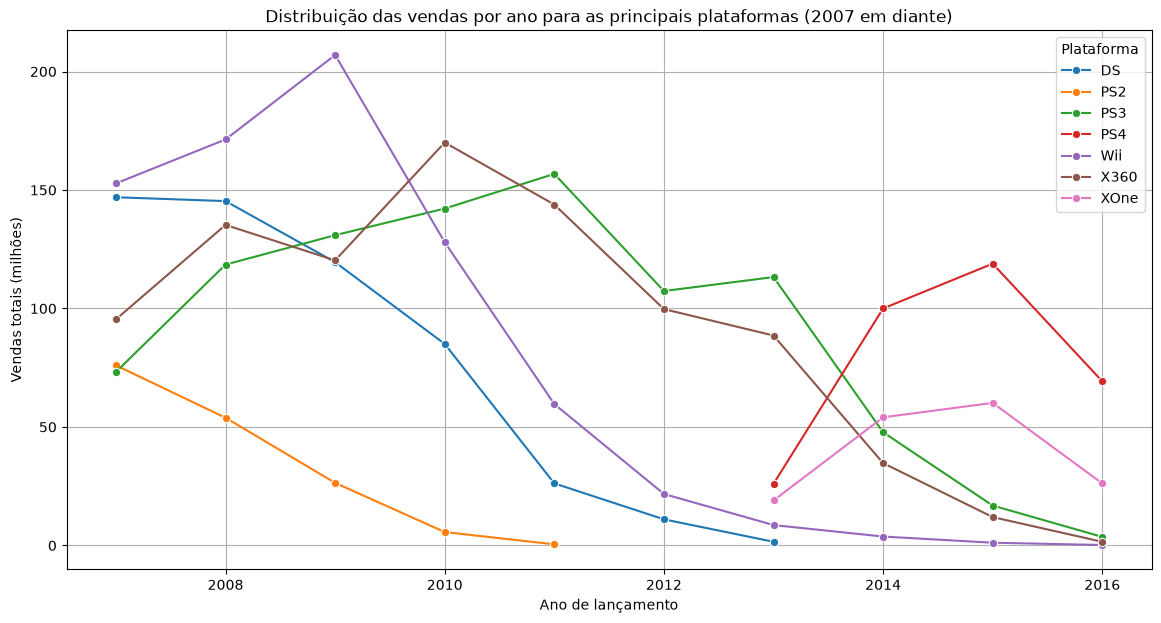

In [13]:
# Analisando o ano inicial de vendas nas principais plataformas, considerando apenas os anos a partir de 2007
print(
    df_games[df_games['year_of_release'] >= 2007]
    .groupby('platform')['year_of_release']
    .min()
    .sort_values(ascending=False)
)
extra_platforms = ['PS4', 'XOne'] # Selecionando as plataformas adicionais para análise
selected_platforms = top_5_platforms + extra_platforms # Combinando as plataformas principais com as adicionais
sales_after_2007 = (
    df_games[(df_games['year_of_release'] >= 2007) & (df_games['platform'].isin(selected_platforms))]
    .groupby(['platform', 'year_of_release'], dropna=False)['total_sales']
    .sum()
    .reset_index()
    .sort_values(['platform', 'year_of_release'])
)
plt.figure(figsize=(14, 7))
sns.lineplot(data=sales_after_2007,
             x='year_of_release',
             y='total_sales',
             hue='platform',
             marker='o') # Criando um gráfico de linha para visualizar a distribuição das vendas por ano para as principais plataformas.
plt.title('Distribuição das vendas por ano para as principais plataformas (2007 em diante)') # Adicionando um título ao gráfico
plt.xlabel('Ano de lançamento') # Adicionando um rótulo ao eixo x
plt.ylabel('Vendas totais (milhões)') # Adicionando um rótulo ao eixo y
plt.legend(title='Plataforma')
plt.grid()
plt.show() # Exibindo o gráfico

### Especificações da tabela

> - O gráfico analisa plataformas com vendas a partir de 2007, incluindo plataformas consolidadas e as plataformas mais recentes.
> - A escolha de apenas 2 plataformas adicionais no gráfico foi para reduzir o ruído e manter a visualização mais clara.


### Ascensão das novas plataformas

No gráfico acima, é possível notar que, a partir de 2007, PS3 e Xbox 360 ainda aparecem com vendas, mas em volumes menores do que nos seus picos anteriores. PS4 e Xbox One surgem mais tarde e mostram um crescimento rápido até cerca de 2015, quando começam a declinar.

Essa análise indica que as plataformas de nova geração tiveram vendas significativas, mas não chegaram a superar de imediato os picos de vendas das plataformas da era anterior, como Wii e PS2. O resultado também reflete um mercado mais fragmentado, em que diferentes gerações de consoles coexistem.

A plataformas mais antigas se mantiveram no topo por 6 anos e após 2010 já demostraram quedas significativas, após 3 anos ja tivemos a inserção de novas plataformas que logo substiruiram a geração anterior

In [ ]:
print(df_games['year_of_release'].value_counts().sort_index().tail(10)) # Analisando a quantidade de jogos lançados nos ultimos 10 anos
df_model = df_games[df_games['year_of_release'] >= 2012] # Criando um modelo para análise considerando apenas os anos de 2012 a 2016



year_of_release
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: Int64


A partir de 2012, o numero de jogos lançados em relaçao a 2011 é quase a metade.